
# Dynamic Hedge Pairs Trading — Hyperparameter Tuning

## `pairs_trading_04_hyperparameter_tuning_yahoo.ipynb`

A copy of `pairs_trading_02_yahoo.ipynb` — the clean end-to-end spine (cointegration screen → Kalman hedge →
walk-forward pair selection → in-sample and OOS evaluation) — with one addition: **§3.6 tunes the
hyperparameters that nb02 hard-codes**, using walk-forward folds on the training window only, and
**§4/§4b evaluate the default and the tuned configuration side by side on the same 2026 hold-out.**

What nb02 fixes by hand and what is tuned here:

| group | hyperparameter | nb02 default | note |
|---|---|---|---|
| Kalman | `q` (transition noise) | 1e-5 | with `em_iters>0` it is only the EM starting value |
| Kalman | `em_iters` | 5 | EM re-estimates Q and R on each training window |
| signals | `z_method` | robust | robust / rolling |
| signals | `z_entry`, `z_exit`, `z_stop` | 2.0 / 0.5 / 4.0 | thresholds on \|z\| |
| signals | `max_hold_bars`, `cooldown_bars` | None / 0 | holding cap, re-entry cooldown |

Everything up to §3.5 is identical to nb02 (the pair is still selected with the default parameters, so
tuning never sees the 2026 data), except that downloaded prices and the screening table are cached
under `notebooks/cache/` (gitignored) to make re-runs cheap.

Re-run from top to bottom; self-contained.


## 0. Environment setup

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().parent           # notebooks/ → repo root
sys.path.insert(0, str(repo_root))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pairs
print("pairs version:", pairs.__version__)
print("pairs path   :", Path(pairs.__file__).relative_to(repo_root))

pairs version: 0.1.0
pairs path   : pairs/__init__.py


In [2]:
# Install the package (editable) if running in a fresh environment
# %pip install -e "..[notebooks]"  # uncomment if needed

# 1. Data Loading & Quality Filtering

We load daily OHLCV prices for the combined S&P 500 + NASDAQ-100 universe
(~517 tickers) over the **training window 2020-01-01 → 2025-12-31**, then
drop tickers whose coverage does not span the full period.

In [3]:
from pairs import load_universe, load_prices

tickers = load_universe("spx_ndx_combined")
print(f"Universe: {len(tickers)} tickers")

Universe: 517 tickers


In [4]:

# ── Load training prices (cached under notebooks/cache/, gitignored) ──────────
start_date = "2020-01-01"
end_date   = "2025-12-31"

CACHE = Path("cache"); CACHE.mkdir(exist_ok=True)
_px_cache = CACHE / "nb04_train_prices.parquet"
if _px_cache.exists():
    df_train, failed = pd.read_parquet(_px_cache), []
    print(f"Loaded cached prices from {_px_cache}")
else:
    df_train, failed = load_prices('openbb', tickers, start_date, end_date, return_failed=True)
    df_train.to_parquet(_px_cache)

print(f"Loaded {len(df_train):,} rows for {df_train.index.get_level_values('ticker').nunique()} tickers")
if failed:
    print("No data for:", failed)


Download:   0%|          | 0/517 [00:00<?, ?it/s]

A:   0%|          | 0/517 [00:00<?, ?it/s]       

A:   0%|          | 1/517 [00:00<08:03,  1.07it/s]

AAPL:   0%|          | 1/517 [00:00<08:03,  1.07it/s]

AAPL:   0%|          | 2/517 [00:01<05:01,  1.71it/s]

...

ZS: 100%|█████████▉| 516/517 [02:54<00:00,  3.63it/s]

ZTS: 100%|█████████▉| 516/517 [02:54<00:00,  3.63it/s]

ZTS: 100%|██████████| 517/517 [02:54<00:00,  3.57it/s]

ZTS: 100%|██████████| 517/517 [02:54<00:00,  2.97it/s]

Loaded 753,000 rows for 505 tickers
No data for: ['AVB', 'BK', 'CTRA', 'DAY', 'EA', 'EQR', 'FI', 'HOLX', 'IPG', 'K', 'MMC', 'WBA']


In [5]:
# ── Quality filter: keep only full-coverage tickers ──────────────────────────
lvl_names      = list(df_train.index.names)
time_lvl_name  = 'datetime' if 'datetime' in lvl_names else lvl_names[1]

full_start = df_train.index.get_level_values(time_lvl_name).min()
full_end   = df_train.index.get_level_values(time_lvl_name).max()

starts = df_train.groupby(level=0).apply(lambda g: g.index.get_level_values(time_lvl_name).min())
ends   = df_train.groupby(level=0).apply(lambda g: g.index.get_level_values(time_lvl_name).max())

tickers_to_keep = starts[(starts == full_start) & (ends == full_end)].index
df_filtered     = df_train.loc[pd.IndexSlice[tickers_to_keep, :]]

n_orig    = df_train.index.get_level_values('ticker').nunique()
n_kept    = df_filtered.index.get_level_values('ticker').nunique()
dropped   = set(tickers) - set(tickers_to_keep)
print(f"Tickers: {n_orig} total → {n_kept} kept ({n_orig - n_kept} dropped for incomplete coverage)")
print(f"Dropped: {sorted(dropped)}")

Tickers: 505 total → 488 kept (17 dropped for incomplete coverage)
Dropped: ['ABNB', 'APP', 'ARM', 'AVB', 'BK', 'CARR', 'CEG', 'COIN', 'CTRA', 'DASH', 'DAY', 'EA', 'EQR', 'EXE', 'FI', 'GEHC', 'GEV', 'GFS', 'HOLX', 'IPG', 'K', 'KVUE', 'MMC', 'OTIS', 'PARA', 'PLTR', 'SOLV', 'VLTO', 'WBA']


# 2. Cointegration Screening

## 2.1 Dual-gate screening (Engle-Granger + Johansen)

We test all $\binom{n}{2}$ pairs simultaneously using two cointegration tests.
A pair advances only if **both** tests reject the null of no cointegration.

In [6]:

from pairs import find_cointegrated_pairs_dualgate

# fdr_method="bh" is the default — BH correction is applied automatically.
# The screen is the slowest step (~120k pairs); cache the result table.
_screen_cache = CACHE / "nb04_screen.parquet"
if _screen_cache.exists():
    summary_dual = pd.read_parquet(_screen_cache)
    print(f"Loaded cached screen from {_screen_cache}")
else:
    summary_dual = find_cointegrated_pairs_dualgate(
        df_filtered,
        alpha_eg=0.05, eg_trend="c",
        alpha_joh=0.05, joh_det_order=0, joh_k_ar_diff=1, joh_stat="trace",
        fdr_method="bh",
        n_workers=16, chunksize=8, show_progress=True,
    )
    summary_dual.to_parquet(_screen_cache)

print(f"\nTotal pairs screened : {len(summary_dual):,}")
print(f"Dual-gate pass (verdict=='pass'): {(summary_dual['verdict']=='pass').sum()}")
print("\nColumn eg_p_fdr contains BH-adjusted p-values:")
summary_dual.head(5)[["eg_t","eg_p","eg_p_fdr","eg_pass","joh_stat","joh_pass","verdict"]]


Dual-gate cointegration (EG + Johansen):   0%|          | 0/118828 [00:00<?, ?it/s]

Dual-gate cointegration (EG + Johansen):   1%|          | 1217/118828 [00:00<00:22, 5284.69it/s]

Dual-gate cointegration (EG + Johansen):   1%|▏         | 1746/118828 [00:01<01:24, 1393.64it/s]

Dual-gate cointegration (EG + Johansen):   2%|▏         | 2002/118828 [00:01<01:47, 1091.72it/s]

Dual-gate cointegration (EG + Johansen):   2%|▏         | 2169/118828 [00:01<01:57, 993.06it/s] 

...

Dual-gate cointegration (EG + Johansen): 100%|█████████▉| 118609/118828 [03:30<00:00, 503.21it/s]

Dual-gate cointegration (EG + Johansen): 100%|█████████▉| 118665/118828 [03:30<00:00, 503.63it/s]

Dual-gate cointegration (EG + Johansen): 100%|█████████▉| 118753/118828 [03:30<00:00, 579.34it/s]


Total pairs screened : 118,828
Dual-gate pass (verdict=='pass'): 279

Column eg_p_fdr contains BH-adjusted p-values:


eg_t          eg_p  eg_p_fdr  eg_pass   joh_stat  \
ticker1 ticker2                                                         
NCLH    SHOP    -6.892330  1.544746e-08  0.001355     True  37.268515   
        TRMB    -6.774412  2.923744e-08  0.001355     True  42.340817   
        XYZ     -6.691579  4.559848e-08  0.001355     True  34.453662   
        ZBRA    -6.725933  3.793752e-08  0.001355     True  36.397732   
        PNC     -6.514035  1.169097e-07  0.002069     True  33.278533   

                 joh_pass verdict  
ticker1 ticker2                    
NCLH    SHOP         True    pass  
        TRMB         True    pass  
        XYZ          True    pass  
        ZBRA         True    pass  
        PNC          True    pass

## 2.2 Multiple Testing Correction — Benjamini-Hochberg (BH) FDR

### Why it matters

We test $N(N-1)/2$ pairs simultaneously at $\alpha = 0.05$.
By chance alone, the expected number of false positives is:
$$
\text{E}[\text{FP}] = \alpha \times M \approx 0.05 \times 121{,}771 \approx 6{,}089
$$

The **Benjamini-Hochberg (1995)** procedure controls the *False Discovery Rate* — the
expected fraction of false positives among all rejected hypotheses — at level $\alpha$.
It is far less conservative than Bonferroni while still being statistically principled.

`find_cointegrated_pairs_dualgate` now:
- applies BH to all EG p-values before gating,
- stores the adjusted p-value in the `eg_p_fdr` column, and
- warns if and how many raw-significant pairs were removed.

In [7]:
from pairs import benjamini_hochberg_fdr

# Post-hoc illustration using the raw EG p-values from summary_dual
alpha_fdr = 0.05
raw_pvals = summary_dual["eg_p"].values
reject_bh, padj = benjamini_hochberg_fdr(raw_pvals, alpha=alpha_fdr)

n_raw = int((raw_pvals <= alpha_fdr).sum())
n_fdr = int(reject_bh.sum())
n_tests = len(raw_pvals)

print(f"Total pairs tested         : {n_tests:>8,}")
print(f"Expected false positives   : {n_tests * alpha_fdr:>8,.0f}  (= {n_tests} × {alpha_fdr})")
print(f"Raw EG significant (p≤.05) : {n_raw:>8,}")
print(f"After BH correction        : {n_fdr:>8,}  ({n_raw - n_fdr:+d} removed)")

Total pairs tested         :  118,828
Expected false positives   :    5,941  (= 118828 × 0.05)
Raw EG significant (p≤.05) :    8,923
After BH correction        :      280  (+8643 removed)


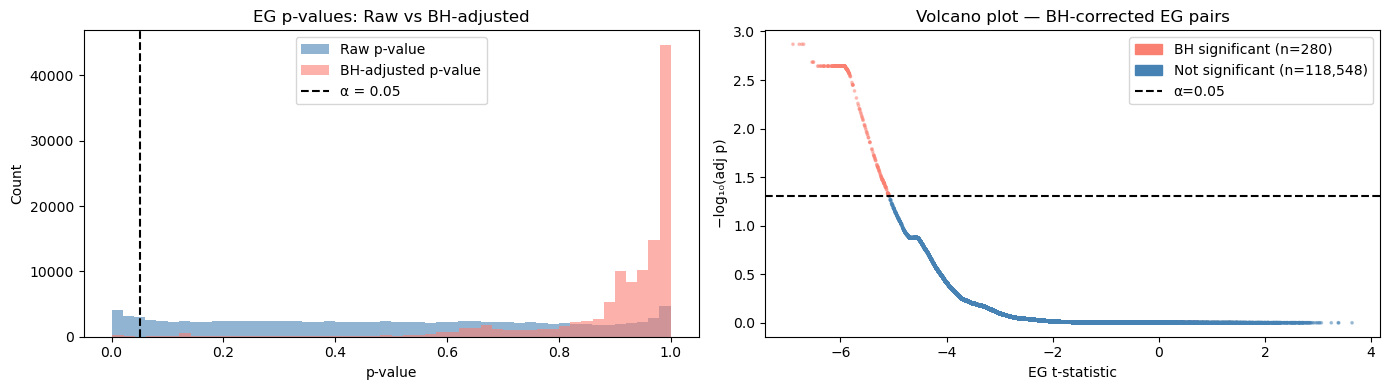


Conclusion: BH removes 8,643 of 8,923 raw-significant pairs, keeping 280 with FDR ≤ 5%.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: histogram of raw vs BH-adjusted p-values
ax = axes[0]
ax.hist(raw_pvals, bins=50, alpha=0.6, label="Raw p-value", color="steelblue")
ax.hist(padj,      bins=50, alpha=0.6, label="BH-adjusted p-value", color="salmon")
ax.axvline(alpha_fdr, color="black", linestyle="--", lw=1.5, label=f"α = {alpha_fdr}")
ax.set_xlabel("p-value"); ax.set_ylabel("Count")
ax.set_title("EG p-values: Raw vs BH-adjusted"); ax.legend()

# Right: volcano plot (t-statistic vs –log10 adj p)
ax = axes[1]
log_padj = -np.log10(np.clip(padj, 1e-300, 1.0))
colours  = np.where(reject_bh, "salmon", "steelblue")
ax.scatter(summary_dual["eg_t"].values, log_padj, c=colours, s=3, alpha=0.4)
ax.axhline(-np.log10(alpha_fdr), color="black", linestyle="--", lw=1.5, label=f"α = {alpha_fdr}")
ax.set_xlabel("EG t-statistic"); ax.set_ylabel("−log₁₀(adj p)")
ax.set_title("Volcano plot — BH-corrected EG pairs")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="salmon",    label=f"BH significant (n={n_fdr:,})"),
    Patch(color="steelblue", label=f"Not significant (n={n_tests-n_fdr:,})"),
    plt.Line2D([0],[0], color="black", linestyle="--", label=f"α={alpha_fdr}"),
])
plt.tight_layout(); plt.show()
print(f"\nConclusion: BH removes {n_raw-n_fdr:,} of {n_raw:,} raw-significant pairs, "
      f"keeping {n_fdr:,} with FDR ≤ {alpha_fdr:.0%}.")

## 2.3 Pre-scoring: rank candidates for Kalman filtering

We rank all pairs by a composite rank score (EG p-value + Johansen statistic) and
take the top 200 as candidates for the computationally expensive Kalman step.

In [9]:
tmp = summary_dual.copy()
tmp["rank_eg"]  = tmp["eg_p"].rank(method="average", ascending=True)
tmp["rank_joh"] = tmp["joh_stat"].rank(method="average", ascending=False)
tmp["pre_score"] = 0.5 * (tmp["rank_eg"] / tmp["rank_eg"].max()
                         + tmp["rank_joh"] / tmp["rank_joh"].max())
prelim     = tmp.sort_values("pre_score", ascending=True)
candidates = prelim.head(200).index.to_list()
print(f"Candidates selected for Kalman filtering: {len(candidates)}")

Candidates selected for Kalman filtering: 200


# 3. Kalman Filter Hedge Estimation & Stationarity Scoring

## 3.1 Kalman filter model overview

We estimate a **time-varying** hedge ratio $\beta_t$ via a linear Gaussian state-space model.

**State (random walk):**
$$
\theta_t = \begin{bmatrix}\beta_t \\ \alpha_t\end{bmatrix}, \qquad
\theta_t = \theta_{t-1} + w_t, \quad w_t \sim \mathcal{N}(0, Q)
$$

**Observation:**
$$
y_t = \alpha_t + \beta_t x_t + v_t, \quad v_t \sim \mathcal{N}(0, R)
$$

Parameters $Q$ and $R$ are learned by EM; the filter is then run in smoother mode
for in-sample residuals and in **filter mode** (no look-ahead) for OOS evaluation.

In [10]:
from pairs import fit_kalman_hedge, summarize_spread_stationarity_joblib

states_tr, params_tr = fit_kalman_hedge(
    df_train,
    pairs=candidates,
    mode="filter",   # causal: the smoother would let each state see the future
    em_iters=5,
    q=1e-5,
    n_workers=None,
    chunksize=100,
    show_progress=True,
    return_params=True,
)
print(f"Kalman states computed for {len(states_tr)} pairs")

Kalman (α_t, β_t):   0%|          | 0/200 [00:00<?, ?it/s]

Kalman (α_t, β_t):   1%|          | 2/200 [00:03<05:25,  1.64s/it]

Kalman (α_t, β_t):   4%|▍         | 8/200 [00:03<01:02,  3.07it/s]

Kalman (α_t, β_t):  11%|█         | 22/200 [00:03<00:16, 10.65it/s]

Kalman (α_t, β_t):  15%|█▌        | 30/200 [00:03<00:11, 15.30it/s]

...

Kalman (α_t, β_t):  95%|█████████▌| 190/200 [00:15<00:00, 18.47it/s]

Kalman (α_t, β_t):  96%|█████████▋| 193/200 [00:15<00:00, 11.96it/s]

Kalman (α_t, β_t):  98%|█████████▊| 196/200 [00:16<00:00, 14.26it/s]

Kalman (α_t, β_t): 100%|██████████| 200/200 [00:16<00:00, 16.99it/s]

Kalman states computed for 200 pairs


## 3.2 Spread stationarity diagnostics

For each pair we run:
1. **ADF** (Augmented Dickey-Fuller) — reject $H_0$ of unit root → spread is I(0)
2. **KPSS** — fail to reject $H_0$ of stationarity → spread is I(0)

**Verdict**: `stationary` if ADF rejects AND KPSS does not reject; `non-stationary` if vice versa;
`inconclusive` otherwise.

Additional diagnostics: **half-life** (AR(1) proxy for mean-reversion speed) and
**residual sigma** (spread volatility).

In [11]:
summary_stationarity = summarize_spread_stationarity_joblib(
    states_tr, alpha=0.05, regression="c", chunksize=256, show_progress=True
)
print(f"\n{len(summary_stationarity)} pairs tested")
summary_stationarity.head(10)

Testing stationarity:   0%|          | 0/200 [00:00<?, ?it/s]

Testing stationarity:   1%|          | 2/200 [00:00<01:26,  2.30it/s]

Testing stationarity:  22%|██▏       | 43/200 [00:00<00:02, 59.73it/s]

Testing stationarity:  60%|██████    | 120/200 [00:01<00:00, 178.53it/s]


200 pairs tested


adf_stat         adf_p  kpss_stat    kpss_p  halflife  \
ticker1 ticker2                                                           
NCLH    ZBH     -27.742492  0.000000e+00   0.464890  0.049574  0.615152   
        VICI    -12.742477  8.883603e-24   0.554256  0.029447  1.525712   
CCL     NWS     -10.183337  6.606414e-18   0.907258  0.010000  2.153599   
        NWSA     -9.949875  2.531373e-17   0.929327  0.010000  2.286437   
NCLH    WY       -9.567755  2.332259e-16   0.562237  0.027649  1.378453   
CCL     GM       -9.044586  5.026671e-15   0.691584  0.014311  0.927928   
        COF      -8.909964  1.111177e-14   0.852376  0.010000  0.733056   
        DLR      -8.896328  1.204185e-14   0.465979  0.049329  0.613365   
        CRM      -8.822649  1.859301e-14   0.677932  0.015552  0.698914   
NCLH    TDY      -8.631832  5.727872e-14   0.465533  0.049430  0.602453   

                 resid_sigma    shapre       verdict  
ticker1 ticker2                                       
NCLH    ZBH         0.272626 -0.013607  inconclusive  
        VICI        0.703102 -0.056798  inconclusive  
CCL     NWS         0.772486 -0.077707  inconclusive  
        NWSA        0.798079 -0.080570  inconclusive  
NCLH    WY          0.645115 -0.048115  inconclusive  
CCL     GM          0.380726  0.012253  inconclusive  
        COF         0.276555 -0.015717  inconclusive  
        DLR         0.215440 -0.041952  inconclusive  
        CRM         0.246573 -0.042969  inconclusive  
NCLH    TDY         0.235948 -0.017003  inconclusive

## 3.3 Composite scoring

Convert heterogeneous metrics into comparable z-scores (higher = better), then take a
weighted sum:

| Metric | Transform | Direction |
|--------|-----------|-----------|
| ADF p-value | $-\log_{10}(p)$ then $Z(\cdot)$ | smaller p → better |
| KPSS p-value | $Z(p)$ | larger p → better |
| Half-life | $-\log(1+\text{hl})$ then $Z(\cdot)$ | shorter → better |
| Residual sigma | $Z(-\sigma)$ | smaller → better |
| Sharpe (train) | $Z(\text{Sharpe})$ | higher → better |

In [12]:
from pairs.stats import Z

final_df = summary_stationarity.copy()
for col in ["adf_p", "kpss_p", "halflife", "resid_sigma", "sharpe_train"]:
    if col in final_df.columns:
        final_df[col] = pd.to_numeric(final_df[col], errors="coerce")

sharpe_series = final_df.get("sharpe_train", pd.Series(0.0, index=final_df.index))
p_adf   = final_df["adf_p"].clip(lower=1e-300, upper=1.0)
p_kpss  = final_df["kpss_p"].clip(lower=1e-300, upper=1.0)
hl_safe = final_df["halflife"].clip(lower=0)

components = {
    "adf":    Z(-np.log10(p_adf)),
    "kpss":   Z(p_kpss),
    "hl":     Z(-np.log1p(hl_safe)),
    "sigma":  Z(-final_df["resid_sigma"]),
    "sharpe": Z(sharpe_series),
}
weights = {k: 1.0 for k in components}
final_df["score"] = sum(weights[k] * components[k] for k in components)
ranked = final_df.sort_values("score", ascending=False)
ranked.head(10)

adf_stat         adf_p  kpss_stat    kpss_p  halflife  \
ticker1 ticker2                                                           
BKNG    MA      -26.184819  0.000000e+00   0.107466  0.100000  0.374708   
AVGO    RL      -20.604764  0.000000e+00   0.038229  0.100000  0.461536   
NCLH    REG     -23.778528  0.000000e+00   0.244832  0.100000  0.886268   
HSIC    PLD     -20.181146  0.000000e+00   0.026152  0.100000  0.827721   
NCLH    ZBH     -27.742492  0.000000e+00   0.464890  0.049574  0.615152   
BA      JKHY    -20.661471  0.000000e+00   0.197209  0.100000  0.670420   
CRM     EQIX    -17.680054  3.611653e-30   0.036575  0.100000  0.204733   
NCLH    SBAC     -9.112234  3.375238e-15   0.339735  0.100000  0.564747   
        VRSN     -9.163560  2.495410e-15   0.294318  0.100000  0.634927   
        WEC      -9.174016  2.346550e-15   0.271572  0.100000  0.688455   

                 resid_sigma    shapre       verdict     score  
ticker1 ticker2                                                 
BKNG    MA          0.363197 -0.001418    stationary  8.740745  
AVGO    RL          0.540440 -0.009011    stationary  8.091029  
NCLH    REG         0.384512 -0.032411    stationary  7.376821  
HSIC    PLD         0.547642 -0.006295    stationary  7.144610  
NCLH    ZBH         0.272626 -0.013607  inconclusive  6.826828  
BA      JKHY        1.547649 -0.002096    stationary  5.291302  
CRM     EQIX        0.306883 -0.001555    stationary  3.965976  
NCLH    SBAC        0.202152 -0.022734    stationary  2.809744  
        VRSN        0.223048 -0.033330    stationary  2.583264  
        WEC         0.292847 -0.028991    stationary  2.294248

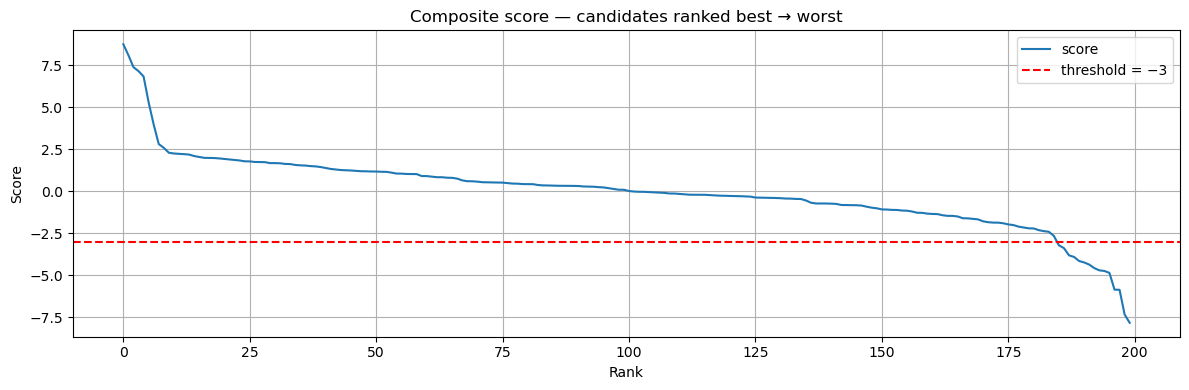

In [13]:
ranked['score'].reset_index(drop=True).plot(
    figsize=(12, 4), grid=True,
    title="Composite score — candidates ranked best → worst",
    xlabel="Rank", ylabel="Score",
)
plt.axhline(-3, color="red", linestyle="--", lw=1.5, label="threshold = −3")
plt.legend(); plt.tight_layout(); plt.show()

In [14]:
ranked_positive = ranked[ranked["score"] > -3]
robust_pairs    = ranked_positive.index
print(f"Candidates: {len(candidates)}  →  Robust pairs (score > −3): {len(robust_pairs)}")

Candidates: 200  →  Robust pairs (score > −3): 185


## 3.4 Pre-filter candidates (composite score)

The composite score from §3.3 is **only a cheap pre-filter** — it narrows the robust pairs down to a short list of candidates. It does **not** pick the traded pair: selecting the single best *in-sample* score is exactly the overfitting trap we want to avoid (it's what produced the inflated CCL/EXPE in-sample Sharpe).

The final pair is chosen in **§3.5** by **walk-forward cross-fold stability**, using only training-span data (2020–2025). The 2026 window (§4b) is never consulted for selection — it stays a genuine held-out test.

In [15]:
# Composite score is a CHEAP PRE-FILTER only — it does NOT pick the final pair.
# Take the top-N robust candidates; the walk-forward driver in §3.5 selects among them.
N_CANDIDATES = 15
wf_candidates = list(robust_pairs[:N_CANDIDATES])

print(f"Pre-filtered to top {len(wf_candidates)} candidates by composite score "
      f"(of {len(robust_pairs)} robust pairs). Final pick is deferred to §3.5.")
for i, (t1, t2) in enumerate(wf_candidates, 1):
    print(f"  {i:2d}. {t1:6s}/{t2:6s}  score={ranked.loc[(t1, t2), 'score']:.3f}")

Pre-filtered to top 15 candidates by composite score (of 185 robust pairs). Final pick is deferred to §3.5.
   1. BKNG  /MA      score=8.741
   2. AVGO  /RL      score=8.091
   3. NCLH  /REG     score=7.377
   4. HSIC  /PLD     score=7.145
   5. NCLH  /ZBH     score=6.827
   6. BA    /JKHY    score=5.291
   7. CRM   /EQIX    score=3.966
   8. NCLH  /SBAC    score=2.810
   9. NCLH  /VRSN    score=2.583
  10. NCLH  /WEC     score=2.294
  11. NCLH  /SJM     score=2.247
  12. NCLH  /WTW     score=2.229
  13. NCLH  /PNW     score=2.208
  14. NCLH  /SPG     score=2.185
  15. NCLH  /NTRS    score=2.095


## 3.5 Walk-forward selection driver  ← *this* picks the traded pair

We run walk-forward validation (rolling train/test folds over the 2020–2025 training span) on **each** pre-filtered candidate and rank by the **median per-fold Sharpe**. Median rewards pairs whose edge is *consistent across folds* rather than pairs that got one lucky window. `MIN_TOTAL_TRADES` screens out pairs too inactive to judge.

This is the holdout principle done correctly for time series: **selection happens on validation folds**; the 2026 test set in §4b is never touched here. The top-ranked pair becomes `ticker1, ticker2` for everything downstream.

The z-score look-back for each test fold is estimated from the *training* fold's residual, which also warms up the rolling window — the test fold never informs its own z-score (no in-fold look-ahead).

In [16]:
# === Walk-forward selection driver (parallel across candidates) =============
# Each candidate's walk-forward run is independent, so we fan them out with joblib.
# walk_forward_backtest is itself serial (no nested parallelism) and the fit uses the
# single-pair _kalman_dynamic_hedge (no internal process pool) — so the only thing to
# guard against is BLAS thread oversubscription. Pin threads to 1 (as the Kalman module
# does internally) before the worker processes are spawned.
import os
for _v in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS", "OMP_NUM_THREADS"):
    os.environ.setdefault(_v, "1")

from joblib import Parallel, delayed
from pairs import walk_forward_backtest, filter_kf_on_new
from pairs.models.kalman import _kalman_dynamic_hedge
from pairs.strategies.signals import generate_pair_signals, estimate_halflife_window
from pairs.strategies.evaluate import evaluate_pair_signals

MIN_TOTAL_TRADES = 12   # skip candidates too inactive to rank reliably
N_JOBS = -1             # -1 = all cores; each job is one candidate's walk-forward

prices_wide_tr = df_filtered.pivot_table(
    index=df_filtered.index.get_level_values("datetime"),
    columns=df_filtered.index.get_level_values("ticker"),
    values="close",
)

def _sel_fit_fn(df_train):
    # Filtered (causal) states so the residual history handed to the test fold has the same
    # statistical properties as the causal test-fold residual; the EM fit and the exported
    # end state are unaffected by the choice of mode.
    _, _, states, params = _kalman_dynamic_hedge(
        "P1", "P2", df_train, q=1e-5, em_iters=5, mode="filter", return_params=True)
    if states is None or params is None:
        return None
    # The z-score look-back is chosen from the TRAINING residual, and that residual is carried
    # along as warm-up history — the test fold never informs its own z-score (no look-ahead).
    params = dict(params)
    params["z_window"]  = estimate_halflife_window(states["resid"])
    params["z_history"] = states["resid"]
    return params

def _sel_signal_fn(df_test, params):
    frozen = {"F": params["F"], "Q": params["Q"], "R": params["R"]}
    last_state = (params["last_state_mean"], params["last_state_cov"])
    states_te, _ = filter_kf_on_new(
        df_test["P1"], df_test["P2"],
        frozen=frozen, last_state=last_state, mode="filter")  # causal, no look-ahead
    df_pair_fold = df_test[["P1", "P2"]].join(states_te[["beta", "resid"]], how="inner")
    return generate_pair_signals(
        df_pair_fold, z_method="robust",
        z_window=params["z_window"], z_history=params["z_history"],   # from the training fold
        z_entry=2.0, z_exit=0.5, z_stop=4.0, capital_per_pair=10_000)

def _sel_eval_fn(df_test, signals):
    _, _, summary = evaluate_pair_signals(
        df_test[["P1", "P2"]], signals,
        cost_bps=1, borrow_bps_per_year=50, days_per_year=252, bars_per_year=252)
    return summary

def _wf_one(t1, t2, df_wf_c, score):
    """Run walk-forward for one candidate; return ('ok', row) / ('error', ...) / None."""
    try:
        res = walk_forward_backtest(
            df_wf_c, train_bars=504, test_bars=126, step_bars=63,
            fit_fn=_sel_fit_fn, signal_fn=_sel_signal_fn, eval_fn=_sel_eval_fn,
            verbose=False)
    except Exception as e:
        return ("error", t1, t2, str(e))
    if res is None or len(res) == 0:
        return None
    s = res["sharpe"].to_numpy(dtype=float)
    n_tr = res["n_trades"].to_numpy(dtype=float)
    return ("ok", {
        "ticker1": t1, "ticker2": t2,
        "wf_sharpe_median": np.nanmedian(s),
        "wf_sharpe_mean":   np.nanmean(s),
        "wf_sharpe_std":    np.nanstd(s),
        "pct_pos_folds":    float(np.mean(s > 0)) if np.isfinite(s).any() else np.nan,
        "wf_trades_total":  int(np.nansum(n_tr)),
        "n_folds":          int(np.isfinite(s).sum()),
        "composite_score":  float(score),
    }, res)

# Build the (small) per-candidate inputs up front; skip pairs with too little history.
_tasks = []
for (t1, t2) in wf_candidates:
    df_wf_c = prices_wide_tr[[t1, t2]].rename(columns={t1: "P1", t2: "P2"}).dropna()
    if len(df_wf_c) < 504 + 126:        # not enough history for even one fold
        continue
    _tasks.append((t1, t2, df_wf_c, float(ranked.loc[(t1, t2), "score"])))

_results = Parallel(n_jobs=N_JOBS, prefer="processes")(
    delayed(_wf_one)(t1, t2, df_wf_c, score) for (t1, t2, df_wf_c, score) in _tasks
)

rows = []
wf_by_pair = {}            # keep each candidate's full per-fold results for reuse
for r in _results:
    if r is None:
        continue
    if r[0] == "error":
        print(f"  skip {r[1]}/{r[2]}: {r[3]}")
        continue
    rows.append(r[1])
    wf_by_pair[(r[1]["ticker1"], r[1]["ticker2"])] = r[2]

wf_selection = pd.DataFrame(rows).set_index(["ticker1", "ticker2"])
wf_selection = wf_selection[wf_selection["wf_trades_total"] >= MIN_TOTAL_TRADES]
wf_selection = wf_selection.sort_values("wf_sharpe_median", ascending=False)

print(f"Ranked {len(wf_selection)} candidates by walk-forward median fold Sharpe "
      f"(>= {MIN_TOTAL_TRADES} total trades):\n")
print(wf_selection.head(10).to_string(float_format="{:.3f}".format))

ticker1, ticker2 = wf_selection.index[0]
wf_results = wf_by_pair[(ticker1, ticker2)]   # winner's folds, for the detail plot below
print(f"\nWalk-forward-selected pair: {ticker1} / {ticker2}")
print("(Composite score chose the SHORTLIST; walk-forward stability chose the PAIR.)")

Ranked 15 candidates by walk-forward median fold Sharpe (>= 12 total trades):

                 wf_sharpe_median  wf_sharpe_mean  wf_sharpe_std  pct_pos_folds  wf_trades_total  n_folds  composite_score
ticker1 ticker2                                                                                                           
BKNG    MA                  1.167           1.094          1.128          0.812              122       16            8.741
NCLH    SPG                 0.618           0.644          1.249          0.750              120       16            2.185
        REG                 0.602           0.307          1.481          0.688              118       16            7.377
        NTRS                0.475           0.416          1.451          0.625              136       16            2.095
        SJM                 0.366           0.349          1.392          0.688              135       16            2.247
AVGO    RL                  0.287           0.236          1

### 3.5.1 Walk-forward detail for the selected pair

§3.5 ranked the shortlist by **median per-fold Sharpe** and selected the pair above. Below is that pair's full per-fold walk-forward distribution — the validation evidence behind the choice, reusing the folds already computed (no recomputation). A tight, mostly-positive distribution is what we want; one that swings sign across folds means the edge is fragile.

=== Walk-forward folds for selected pair BKNG/MA ===

                  mean   std  median    min    max
sharpe           1.094 1.165   1.167 -0.931  3.054
ann_return       0.063 0.071   0.055 -0.049  0.175
max_drawdown_pct 0.024 0.015   0.018  0.008  0.065
n_trades         7.625 2.553   8.000  3.000 11.000
hit_rate         0.714 0.171   0.697  0.333  1.000
profit_factor      inf   NaN   4.408  0.332    inf


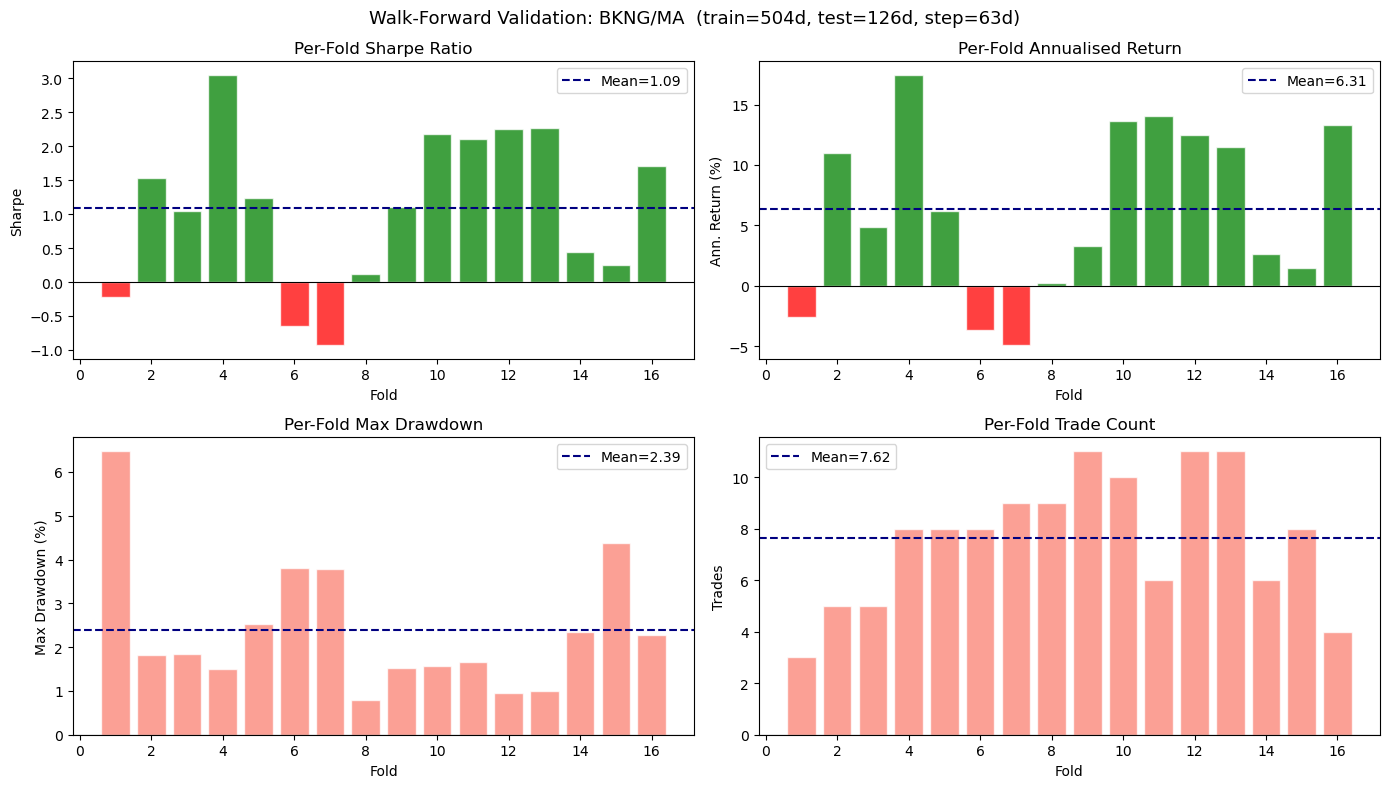


Folds with positive Sharpe : 81%  (13/16)
Median fold Sharpe         : 1.17
Mean fold Sharpe           : 1.09  (std=1.13)


In [17]:
# Per-fold walk-forward detail for the SELECTED pair — reuses wf_results from §3.5
# (no recomputation). nan-robust stats (a zero-trade fold yields a NaN Sharpe).
from pairs.validation.walk_forward import summarize_walk_forward

print(f"=== Walk-forward folds for selected pair {ticker1}/{ticker2} ===\n")
print(summarize_walk_forward(wf_results).to_string(float_format="{:.3f}".format))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f"Walk-Forward Validation: {ticker1}/{ticker2}  "
             f"(train=504d, test=126d, step=63d)", fontsize=13)

sharpes  = wf_results["sharpe"].to_numpy(dtype=float)
ann_rets = wf_results["ann_return"].to_numpy(dtype=float) * 100
dds      = wf_results["max_drawdown_pct"].abs().to_numpy(dtype=float) * 100
n_trades = wf_results["n_trades"].to_numpy(dtype=float)
folds    = wf_results.index.values

def _bar(ax, vals, title, ylabel, pos_neg=True):
    colors = ["green" if v > 0 else "red" for v in vals] if pos_neg else "salmon"
    ax.bar(folds, vals, color=colors, alpha=0.75, edgecolor="white")
    ax.axhline(0, color="black", lw=0.8)
    ax.axhline(np.nanmean(vals), color="navy", linestyle="--", lw=1.5,
               label=f"Mean={np.nanmean(vals):.2f}")
    ax.set_xlabel("Fold"); ax.set_ylabel(ylabel); ax.set_title(title); ax.legend()

_bar(axes[0, 0], sharpes,  "Per-Fold Sharpe Ratio",      "Sharpe")
_bar(axes[0, 1], ann_rets, "Per-Fold Annualised Return", "Ann. Return (%)")
_bar(axes[1, 0], dds,      "Per-Fold Max Drawdown",      "Max Drawdown (%)", pos_neg=False)
_bar(axes[1, 1], n_trades, "Per-Fold Trade Count",       "Trades", pos_neg=False)
plt.tight_layout(); plt.show()

pct_pos = float(np.mean(sharpes > 0)) * 100
print(f"\nFolds with positive Sharpe : {pct_pos:.0f}%  ({int((sharpes > 0).sum())}/{len(sharpes)})")
print(f"Median fold Sharpe         : {np.nanmedian(sharpes):.2f}")
print(f"Mean fold Sharpe           : {np.nanmean(sharpes):.2f}  (std={np.nanstd(sharpes):.2f})")

## 3.6 Hyperparameter tuning — walk-forward on the training window only

nb02 picks the pair with a walk-forward driver but runs it with hand-set parameters. Here the same
folds (train 504 / test 126 / step 63 bars, 2020–2025) score a grid of configurations for the selected
pair. The objective is the **pooled out-of-fold Sharpe**: the out-of-fold daily net returns of all folds
are concatenated into one series and a single annualised Sharpe is computed on it, with a fixed $10k
capital base so returns are comparable across folds. Because the 126-bar test windows overlap (step 63),
each fold contributes only the 63 bars before the next refit (the last fold contributes all of its bars),
so every bar from bar 505 onward has exactly one out-of-fold return, from the most recently refitted
model — the way a live rolling re-estimation would trade. A configuration that sits flat most of the time
is not rewarded for it: flat days enter the series at zero. nb02's own selection metric, the *median* of
the per-fold Sharpes, is kept as a secondary column, and configurations with fewer than
`MIN_TOTAL_TRADES` trades across the folds are discarded.

The search is structured so that the expensive part is done once:

1. For each Kalman setting `(q, em_iters)` the filter is fitted on every training fold and run
   *causally* on the matching test fold (exactly `_sel_fit_fn` / `_sel_signal_fn` from §3.5). That gives
   per-fold frames with `P1, P2, beta, resid`. As in nb02's driver, the z-score look-back and its warm-up
   history come from the training fold's residual, never from the test fold.
2. Every signal configuration is then evaluated on those frames, which costs milliseconds per fold.

Nothing here touches 2026 data; the hold-out test in §4b is the only place the tuned configuration is
compared with the default on unseen prices.

In [18]:
from itertools import product
from pairs.validation import walk_forward_splits

TRAIN_BARS, TEST_BARS, STEP_BARS = 504, 126, 63     # same folds as the §3.5 selection driver

HP_DEFAULT = dict(q=1e-5, em_iters=5,                                    # nb02's hard-coded values
                  z_method="robust", z_entry=2.0, z_exit=0.5, z_stop=4.0,
                  max_hold_bars=None, cooldown_bars=0)
KALMAN_KEYS = ("q", "em_iters")
SIGNAL_KEYS = ("z_method", "z_entry", "z_exit", "z_stop", "max_hold_bars", "cooldown_bars")

KALMAN_GRID = [dict(q=q, em_iters=em) for q in (1e-6, 1e-5, 1e-4, 1e-3) for em in (0, 5)]
SIGNAL_GRID = [dict(z_method=m, z_entry=e, z_exit=x, z_stop=s, max_hold_bars=h, cooldown_bars=c)
               for m in ("robust", "rolling")
               for e in (1.5, 2.0, 2.5, 3.0)
               for x in (0.0, 0.5, 1.0)
               for s in (3.5, 4.0, 5.0)
               for h in (None, 60)
               for c in (0, 5)]
assert any({**k, **s} == HP_DEFAULT for k in KALMAN_GRID for s in SIGNAL_GRID), "default must be on the grid"
print(f"{len(KALMAN_GRID)} Kalman settings × {len(SIGNAL_GRID)} signal settings = "
      f"{len(KALMAN_GRID) * len(SIGNAL_GRID):,} configurations")

df_sel = prices_wide_tr[[ticker1, ticker2]].rename(columns={ticker1: "P1", ticker2: "P2"}).dropna()
splits = walk_forward_splits(df_sel.index, train_bars=TRAIN_BARS, test_bars=TEST_BARS, step_bars=STEP_BARS)
print(f"{ticker1}/{ticker2}: {len(df_sel):,} training bars → {len(splits)} walk-forward folds")

8 Kalman settings × 288 signal settings = 2,304 configurations
BKNG/MA: 1,508 training bars → 16 walk-forward folds


In [19]:
# ── Step 1: Kalman fits per fold, per (q, em_iters) — done once ─────────────────
def _kalman_key(q, em_iters):
    return f"q={q:g}, em={em_iters}"

def _fold_frame(df_train_f, df_test_f, q, em_iters):
    # Same mechanics as _sel_fit_fn + _sel_signal_fn in §3.5: EM fit on the train fold (filtered
    # states, so the residual history is causal), then continue the filter causally on the test
    # fold. The z-score look-back and its warm-up history come from the TRAIN fold only.
    _, _, states, params = _kalman_dynamic_hedge("P1", "P2", df_train_f, q=q, em_iters=em_iters,
                                                 mode="filter", return_params=True)
    if states is None or params is None:
        return None
    frozen = {"F": params["F"], "Q": params["Q"], "R": params["R"]}
    states_te, _ = filter_kf_on_new(df_test_f["P1"], df_test_f["P2"], frozen=frozen,
                                    last_state=(params["last_state_mean"], params["last_state_cov"]),
                                    mode="filter")
    return {"frame": df_test_f[["P1", "P2"]].join(states_te[["beta", "resid"]], how="inner"),
            "z_window": estimate_halflife_window(states["resid"]),
            "z_history": states["resid"]}

def _fold_frames_for(df_pair_full, splits_, q, em_iters):
    warnings.filterwarnings("ignore")
    return [_fold_frame(df_pair_full.loc[tr], df_pair_full.loc[te], q, em_iters) for tr, te in splits_]

import time
t0 = time.time()
_frames = Parallel(n_jobs=N_JOBS)(delayed(_fold_frames_for)(df_sel, splits, **k) for k in KALMAN_GRID)
fold_frames = {_kalman_key(**k): f for k, f in zip(KALMAN_GRID, _frames)}
print(f"Kalman fold fits: {len(KALMAN_GRID)} settings × {len(splits)} folds in {time.time() - t0:.0f}s")

Kalman fold fits: 8 settings × 16 folds in 5s


In [20]:
# ── Step 2: evaluate every signal configuration on the precomputed folds ─────────
EVAL_KW = dict(cost_bps=1, borrow_bps_per_year=50, days_per_year=252, bars_per_year=252,
               capital_base=10_000)      # fixed base: out-of-fold returns are comparable across folds

def _pooled_sharpe(n, s1, s2, periods=252):
    # Annualised Sharpe of a return series known only through its count, sum and sum of squares
    # (mean / population std). Lets any subset of folds be pooled without keeping the returns.
    n = np.asarray(n, float); s1 = np.asarray(s1, float); s2 = np.asarray(s2, float)
    with np.errstate(divide="ignore", invalid="ignore"):
        mean = s1 / n
        var = s2 / n - mean ** 2
        out = mean / np.sqrt(var) * np.sqrt(periods)
    return np.where((n >= 2) & (var > 0), out, np.nan)

def _oof_slices(frames, scfg):
    # Per-fold out-of-fold daily results, keeping only the bars before the next refit
    # (the last fold keeps all of them) so each bar appears exactly once.
    out = []
    for k, f in enumerate(frames):
        fr = None if f is None else f["frame"]
        if fr is None or len(fr) < 30:
            out.append(None); continue
        sig = generate_pair_signals(fr, capital_per_pair=10_000,
                                    z_window=f["z_window"], z_history=f["z_history"], **scfg)
        daily, _, summ = evaluate_pair_signals(fr[["P1", "P2"]], sig, **EVAL_KW)
        if k < len(frames) - 1:
            daily = daily.iloc[:STEP_BARS]
        out.append((daily, summ))
    return out

def _eval_config(kcfg, scfg, frames):
    warnings.filterwarnings("ignore")
    n_f = len(frames)
    sharpes, trades = [], 0
    fold_n = np.zeros(n_f); fold_s1 = np.zeros(n_f); fold_s2 = np.zeros(n_f)
    for k, item in enumerate(_oof_slices(frames, scfg)):
        if item is None:
            sharpes.append(np.nan); continue
        daily, summ = item
        sharpes.append(summ["sharpe"]); trades += int(summ["n_trades"])   # per-fold stats on the full 126-bar window
        r = daily["ret_net"].to_numpy(float); r = r[np.isfinite(r)]
        fold_n[k], fold_s1[k], fold_s2[k] = len(r), r.sum(), (r ** 2).sum()
    s = np.asarray(sharpes, float)
    return {**kcfg, **scfg,
            "oof_sharpe":       float(_pooled_sharpe(fold_n.sum(), fold_s1.sum(), fold_s2.sum())),
            "oof_ann_return":   float(fold_s1.sum() / max(fold_n.sum(), 1) * 252),    # arithmetic, on the $10k base
            "wf_sharpe_median": np.nanmedian(s) if np.isfinite(s).any() else np.nan,
            "wf_sharpe_mean":   np.nanmean(s)   if np.isfinite(s).any() else np.nan,
            "pct_pos_folds":    float(np.mean(s > 0)),
            "wf_trades_total":  trades,
            "n_folds":          int(np.isfinite(s).sum()),
            "fold_sharpes":     s, "fold_n": fold_n, "fold_s1": fold_s1, "fold_s2": fold_s2}

t0 = time.time()
tuning = pd.DataFrame(Parallel(n_jobs=N_JOBS, batch_size=32)(
    delayed(_eval_config)(k, s, fold_frames[_kalman_key(**k)]) for k in KALMAN_GRID for s in SIGNAL_GRID))
print(f"{len(tuning):,} configurations × {len(splits)} folds evaluated in {time.time() - t0:.0f}s")

def _match(df, cfg):
    # None (max_hold_bars) becomes NaN inside a DataFrame column, so compare with isna() there.
    m = np.ones(len(df), dtype=bool)
    for k, v in cfg.items():
        m &= (df[k].isna() if v is None else (df[k] == v)).to_numpy()
    return m

default_row = tuning[_match(tuning, HP_DEFAULT)].iloc[0]
OBJECTIVE = "oof_sharpe"
valid = (tuning[tuning["wf_trades_total"] >= MIN_TOTAL_TRADES]
         .dropna(subset=[OBJECTIVE])
         .sort_values(OBJECTIVE, ascending=False, kind="mergesort"))   # stable: ties keep grid order (simplest first)
print(f"{len(valid):,} configurations with ≥ {MIN_TOTAL_TRADES} total trades\n")

show_cols = list(KALMAN_KEYS + SIGNAL_KEYS) + ["oof_sharpe", "oof_ann_return", "wf_sharpe_median", "pct_pos_folds", "wf_trades_total"]
print("Top 10 configurations by pooled out-of-fold Sharpe:")
print(valid[show_cols].head(10).to_string(index=False, float_format="{:.3f}".format))
print("\nnb02 default configuration:")
print(default_row[show_cols].to_frame().T.to_string(index=False, float_format="{:.3f}".format))
print(f"\nDefault ranks {int((valid[OBJECTIVE] > default_row[OBJECTIVE]).sum()) + 1} "
      f"of {len(valid)} valid configurations.")

2,304 configurations × 16 folds evaluated in 34s
1,802 configurations with ≥ 12 total trades

Top 10 configurations by pooled out-of-fold Sharpe:
    q  em_iters z_method  z_entry  z_exit  z_stop  max_hold_bars  cooldown_bars  oof_sharpe  oof_ann_return  wf_sharpe_median  pct_pos_folds  wf_trades_total
0.001         0   robust    2.000   0.500   5.000            NaN              0       1.364           0.082             1.387          0.812              117
0.001         0   robust    2.000   0.500   5.000         60.000              0       1.364           0.082             1.387          0.812              117
0.001         0   robust    2.000   0.500   4.000            NaN              0       1.251           0.071             1.429          0.688              112
0.001         0   robust    2.000   0.500   4.000         60.000              0       1.251           0.071             1.429          0.688              112
0.001         0   robust    2.000   0.500   5.000            NaN

### 3.6.1 What matters and what does not

Marginal effect of each hyperparameter: the distribution of pooled out-of-fold Sharpe across all
configurations sharing a value (box = interquartile range across the other seven dimensions). A flat
row means the parameter does not matter much on this pair; a steep one is where the tuning gain comes
from.

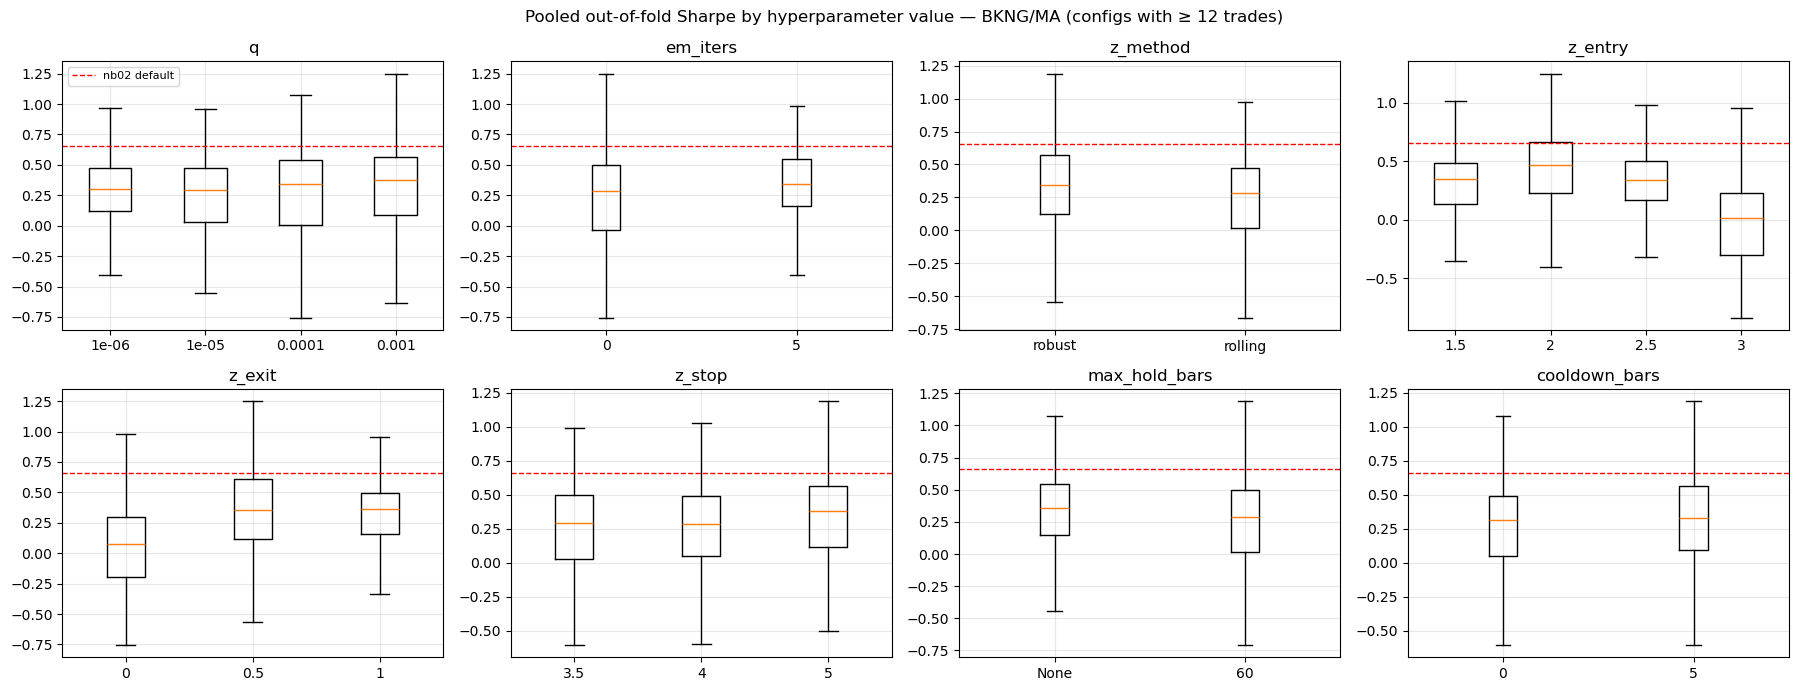

In [21]:
def _value_labels(series):
    # Human-readable group labels in a sensible order: 'None' first, then numeric ascending, or strings sorted.
    if pd.api.types.is_numeric_dtype(series):
        labels = series.map(lambda v: "None" if pd.isna(v) else f"{v:g}")
        order = (["None"] if series.isna().any() else []) + [f"{v:g}" for v in sorted(series.dropna().unique())]
    else:                                        # string-valued (pandas 3 'str' dtype or object)
        labels = series.astype(str); order = sorted(labels.unique())
    return labels, order

params_to_plot = list(KALMAN_KEYS + SIGNAL_KEYS)
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, p in zip(axes.ravel(), params_to_plot):
    labels, order = _value_labels(valid[p])
    groups = valid.groupby(labels, sort=False)[OBJECTIVE]
    data = [groups.get_group(g).values for g in order if g in groups.groups]
    ticks = [g for g in order if g in groups.groups]
    ax.boxplot(data, showfliers=False)
    ax.set_xticks(range(1, len(ticks) + 1), ticks)      # works on matplotlib < 3.9 too
    ax.axhline(default_row[OBJECTIVE], color="red", ls="--", lw=1, label="nb02 default")
    ax.set_title(p); ax.grid(alpha=0.3)
    if p == params_to_plot[0]: ax.legend(fontsize=8)
fig.suptitle(f"Pooled out-of-fold Sharpe by hyperparameter value — {ticker1}/{ticker2} (configs with ≥ {MIN_TOTAL_TRADES} trades)")
plt.tight_layout(); plt.show()

### 3.6.2 How much of the improvement is selection bias?

Picking the maximum over a couple of thousand configurations guarantees a flattering in-sample number
even when nothing is really better. Two cheap checks before believing the winner:

* **Where the default sits** in the distribution of all configurations, and how far the top of the
  distribution is from its bulk (a lone outlier at the top is more suspicious than a plateau of similar
  configurations).
* **Split-half rank stability**: rank every configuration by its pooled Sharpe on the odd folds and
  again on the even folds. If tuning is finding structure rather than noise, the two rankings agree
  (Spearman correlation well above zero) and the winner on one half is near the top on the other.

The decisive check is the 2026 hold-out in §4b, which none of this has touched.

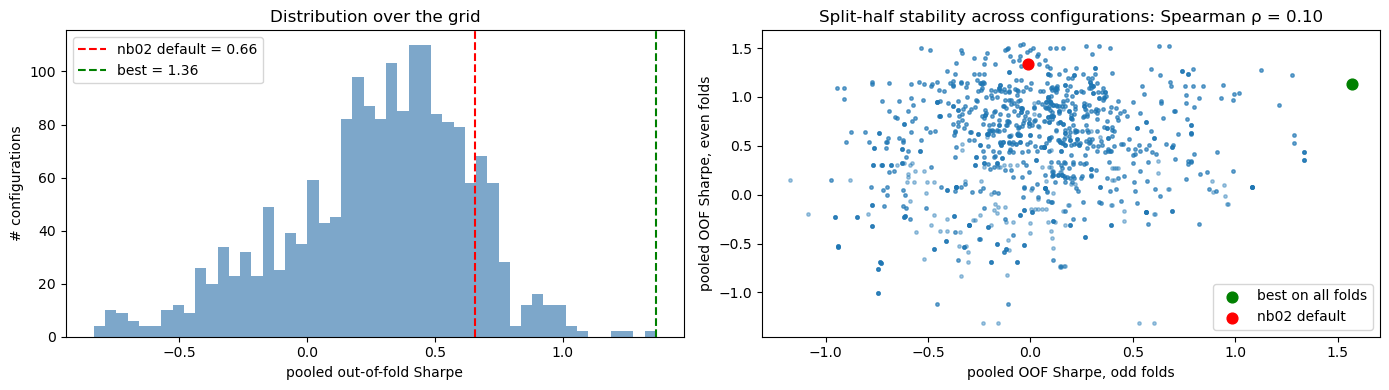

Top-20 configs by odd-fold Sharpe have median even-fold rank 969 of 1786  (pure noise would give ≈ 893).


In [22]:
from scipy.stats import spearmanr

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
ax.hist(valid[OBJECTIVE], bins=50, color="steelblue", alpha=0.7)
ax.axvline(default_row[OBJECTIVE], color="red", ls="--", label=f"nb02 default = {default_row[OBJECTIVE]:.2f}")
ax.axvline(valid[OBJECTIVE].iloc[0], color="green", ls="--", label=f"best = {valid[OBJECTIVE].iloc[0]:.2f}")
ax.set_xlabel("pooled out-of-fold Sharpe"); ax.set_ylabel("# configurations"); ax.legend()
ax.set_title("Distribution over the grid")

# split-half rank stability: pooled Sharpe over the odd folds vs over the even folds
N_, S1_, S2_ = (np.vstack(valid[c].values) for c in ("fold_n", "fold_s1", "fold_s2"))   # configs × folds
odd  = _pooled_sharpe(N_[:, 0::2].sum(1), S1_[:, 0::2].sum(1), S2_[:, 0::2].sum(1))
even = _pooled_sharpe(N_[:, 1::2].sum(1), S1_[:, 1::2].sum(1), S2_[:, 1::2].sum(1))
ok = np.isfinite(odd) & np.isfinite(even)
rho = spearmanr(odd[ok], even[ok]).correlation
ax = axes[1]
ax.scatter(odd[ok], even[ok], s=6, alpha=0.4)
ax.scatter(odd[0], even[0], color="green", s=60, label="best on all folds", zorder=3)
if default_row.name in valid.index:            # the default may have too few trades to be 'valid'
    d_i = int(np.where(valid.index == default_row.name)[0][0])
    ax.scatter(odd[d_i], even[d_i], color="red", s=60, label="nb02 default", zorder=3)
ax.set_xlabel("pooled OOF Sharpe, odd folds"); ax.set_ylabel("pooled OOF Sharpe, even folds")
ax.set_title(f"Split-half stability across configurations: Spearman ρ = {rho:.2f}"); ax.legend()
plt.tight_layout(); plt.show()

top_k = 20
rank_even = pd.Series(even, index=valid.index).rank(ascending=False)
print(f"Top-{top_k} configs by odd-fold Sharpe have median even-fold rank "
      f"{rank_even.loc[valid.index[np.argsort(-odd)[:top_k]]].median():.0f} of {ok.sum()}  "
      f"(pure noise would give ≈ {ok.sum() / 2:.0f}).")

### 3.6.3 Choose the tuned configuration, and check it transfers

The winner is the best pooled out-of-fold Sharpe among configurations with enough trades. As a guard
against a configuration that is idiosyncratic to the selected pair, the same configuration is
re-scored on the next three candidates from the §3.5 shortlist (each with its own walk-forward folds):
a genuine improvement in the *strategy* should not evaporate on neighbouring pairs.

In [23]:
TUNED = {k: valid.iloc[0][k] for k in KALMAN_KEYS + SIGNAL_KEYS}
TUNED["q"] = float(TUNED["q"]); TUNED["em_iters"] = int(TUNED["em_iters"])
TUNED["max_hold_bars"] = None if pd.isna(TUNED["max_hold_bars"]) else int(TUNED["max_hold_bars"])
TUNED["cooldown_bars"] = int(TUNED["cooldown_bars"])
for k in ("z_entry", "z_exit", "z_stop"): TUNED[k] = float(TUNED[k])

print("Tuned configuration:")
for k in KALMAN_KEYS + SIGNAL_KEYS:
    flag = "" if TUNED[k] == HP_DEFAULT[k] else "   ← changed"
    print(f"  {k:14s} {str(HP_DEFAULT[k]):>8s} → {str(TUNED[k]):<8s}{flag}")

def _wf_score(pair, cfg):
    t1, t2 = pair
    dfp = prices_wide_tr[[t1, t2]].rename(columns={t1: "P1", t2: "P2"}).dropna()
    sp = walk_forward_splits(dfp.index, train_bars=TRAIN_BARS, test_bars=TEST_BARS, step_bars=STEP_BARS)
    frames = _fold_frames_for(dfp, sp, cfg["q"], cfg["em_iters"])
    return _eval_config({k: cfg[k] for k in KALMAN_KEYS}, {k: cfg[k] for k in SIGNAL_KEYS}, frames)

others = [p for p in wf_selection.index if p != (ticker1, ticker2)][:3]
jobs = [(p, name, cfg) for p in [(ticker1, ticker2)] + others for name, cfg in (("default", HP_DEFAULT), ("tuned", TUNED))]
res = Parallel(n_jobs=N_JOBS)(delayed(_wf_score)(p, cfg) for p, name, cfg in jobs)
transfer = pd.DataFrame([{"pair": f"{p[0]}/{p[1]}", "config": name,
                          "oof_sharpe": r["oof_sharpe"], "wf_sharpe_median": r["wf_sharpe_median"],
                          "wf_trades_total": r["wf_trades_total"]} for (p, name, cfg), r in zip(jobs, res)])
transfer = transfer.pivot(index="pair", columns="config", values=["oof_sharpe", "wf_sharpe_median", "wf_trades_total"])
transfer = transfer.reindex([f"{p[0]}/{p[1]}" for p in [(ticker1, ticker2)] + others])
print("\nPooled out-of-fold Sharpe of the default vs tuned configuration (selected pair first, then runner-ups):")
print(transfer.to_string(float_format="{:.3f}".format))

Tuned configuration:
  q                 1e-05 → 0.001      ← changed
  em_iters              5 → 0          ← changed
  z_method         robust → robust  
  z_entry             2.0 → 2.0     
  z_exit              0.5 → 0.5     
  z_stop              4.0 → 5.0        ← changed
  max_hold_bars      None → None    
  cooldown_bars         0 → 0       



Pooled out-of-fold Sharpe of the default vs tuned configuration (selected pair first, then runner-ups):
          oof_sharpe       wf_sharpe_median       wf_trades_total        
config       default tuned          default tuned         default   tuned
pair                                                                     
BKNG/MA        0.658 1.364            1.167 1.387         122.000 117.000
NCLH/SPG       0.615 0.096            0.618 0.474         120.000 153.000
NCLH/REG       0.091 0.720            0.602 0.648         118.000 138.000
NCLH/NTRS      0.638 0.915            0.475 1.107         136.000 151.000


### 3.6.4 Pooled out-of-fold equity: the honest in-sample view

The curves in §4 are in-sample in the ordinary sense: the Kalman filter is fitted by EM on the whole
training window and then run causally through it, so each bar's state uses only its own past but the
noise parameters were chosen with the window in hand. The curve below is stricter, and is what the tuning
actually scored: each fold's filter is fitted only on the bars before that fold. Where the two disagree,
this one is the yardstick.

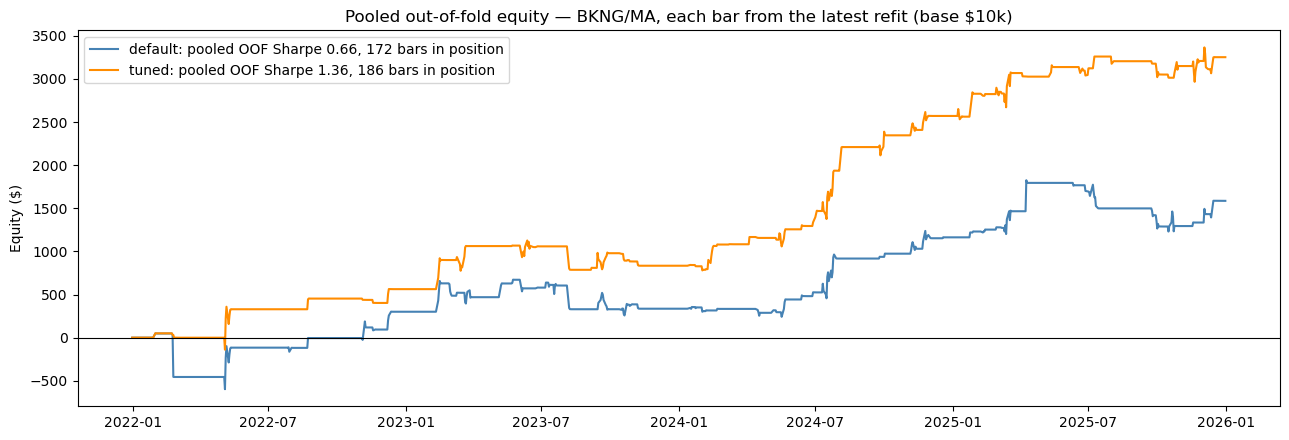

Out-of-fold bars: 1004  (2021-12-31 → 2025-12-31)


In [24]:
def _oof_daily(frames, cfg):
    parts = [d for d, _ in (x for x in _oof_slices(frames, {k: cfg[k] for k in SIGNAL_KEYS}) if x is not None)]
    return pd.concat(parts).sort_index()

oof = {name: _oof_daily(fold_frames[_kalman_key(cfg["q"], cfg["em_iters"])], cfg)
       for name, cfg in (("default", HP_DEFAULT), ("tuned", TUNED))}

fig, ax = plt.subplots(figsize=(13, 4.5))
for name, color in (("default", "steelblue"), ("tuned", "darkorange")):
    d = oof[name]
    sh = float(_pooled_sharpe(len(d), d["ret_net"].sum(), (d["ret_net"] ** 2).sum()))
    ax.plot(d.index, d["pnl_net"].cumsum(), color=color, lw=1.5,
            label=f"{name}: pooled OOF Sharpe {sh:.2f}, {int(d['in_pos'].sum())} bars in position")
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"Pooled out-of-fold equity — {ticker1}/{ticker2}, each bar from the latest refit (base $10k)")
ax.set_ylabel("Equity ($)"); ax.legend(); plt.tight_layout(); plt.show()
print(f"Out-of-fold bars: {len(oof['default'])}  ({oof['default'].index[0].date()} → {oof['default'].index[-1].date()})")


# 4. In-Sample Signal Generation & Evaluation (2020–2025) — default vs tuned

Same steps as nb02, run twice: once with nb02's defaults and once with the tuned configuration.
The tuned Kalman setting needs its own fit on the full training window (nb02's `states_tr`
were fitted with `q=1e-5, em_iters=5`).


In [25]:

prices = df_filtered.pivot_table(
    index=df_filtered.index.get_level_values('datetime'),
    columns=df_filtered.index.get_level_values('ticker'),
    values='close',
)
pair = (ticker1, ticker2)

# default Kalman states: from §3 (q=1e-5, em_iters=5)
df_pair = pd.DataFrame({'P1': prices[ticker1], 'P2': prices[ticker2]}).join(states_tr[pair][['beta', 'resid']])

# tuned Kalman states: refit on the full training window with the tuned (q, em_iters)
states_tuned, params_tuned = fit_kalman_hedge(
    df_train, pairs=[pair], mode="filter",   # causal, as in nb02
    q=TUNED["q"], em_iters=TUNED["em_iters"], show_progress=False, return_params=True,
)
df_pair_tuned = pd.DataFrame({'P1': prices[ticker1], 'P2': prices[ticker2]}).join(states_tuned[pair][['beta', 'resid']])

print(f"Training pair frame: {df_pair.index[0].date()} → {df_pair.index[-1].date()}, {len(df_pair):,} bars")
print(f"Kalman (default) Q diag: {np.diag(params_tr[pair]['Q'])},  R: {params_tr[pair]['R'].ravel()}")
print(f"Kalman (tuned)   Q diag: {np.diag(params_tuned[pair]['Q'])},  R: {params_tuned[pair]['R'].ravel()}")
df_pair_tuned.tail(3)


Training pair frame: 2020-01-02 → 2025-12-31, 1,508 bars
Kalman (default) Q diag: [1.74262738e-05 9.85812651e-06],  R: [0.76388661]
Kalman (tuned)   Q diag: [0.001 0.001],  R: [1.]


,P1,P2,beta,resid
datetime,,,,
2025-12-29,217.653198,577.900024,0.344527,0.001877
2025-12-30,217.085999,577.419983,0.343837,-0.001192
2025-12-31,214.213196,570.880005,0.342752,-0.001907


## 4.2 Generate trading signals

Signal logic:
- **Entry**: |z| > `z_entry` (default 2.0) — spread is extreme
- **Exit** : |z| < `z_exit`  (default 0.5) — spread has mean-reverted
- **Stop** : |z| > `z_stop`  (default 4.0) — spread is diverging

Z-score is computed with the *robust* method (median/MAD) which is less sensitive to outliers.

In [26]:

from pairs.strategies import generate_pair_signals

SIG_DEFAULT = {k: HP_DEFAULT[k] for k in SIGNAL_KEYS}
SIG_TUNED   = {k: TUNED[k] for k in SIGNAL_KEYS}

signals       = generate_pair_signals(df_pair,       capital_per_pair=10_000, **SIG_DEFAULT)
signals_tuned = generate_pair_signals(df_pair_tuned, capital_per_pair=10_000, **SIG_TUNED)
print(f"in-sample trades — default: {int(signals['entry'].sum())}, tuned: {int(signals_tuned['entry'].sum())}")
signals_tuned.tail(5)


in-sample trades — default: 85, tuned: 83


,z,pos,n1,n2,entry,exit,stop
datetime,,,,,,,
2025-12-24,-0.340304,0,0.0,0.0,False,False,False
2025-12-26,-0.113940,0,0.0,0.0,False,False,False
2025-12-29,0.050330,0,0.0,0.0,False,False,False
2025-12-30,-0.150623,0,0.0,0.0,False,False,False
2025-12-31,-0.245014,0,0.0,0.0,False,False,False


## 4.3 Visualise in-sample trades (tuned configuration)

(<Figure size 1300x800 with 2 Axes>,
 (<Axes: ylabel='Price'>,
  <Axes: title={'center': 'Trades superimposed on each leg • BKNG (top), MA (bottom)'}, ylabel='Price'>))

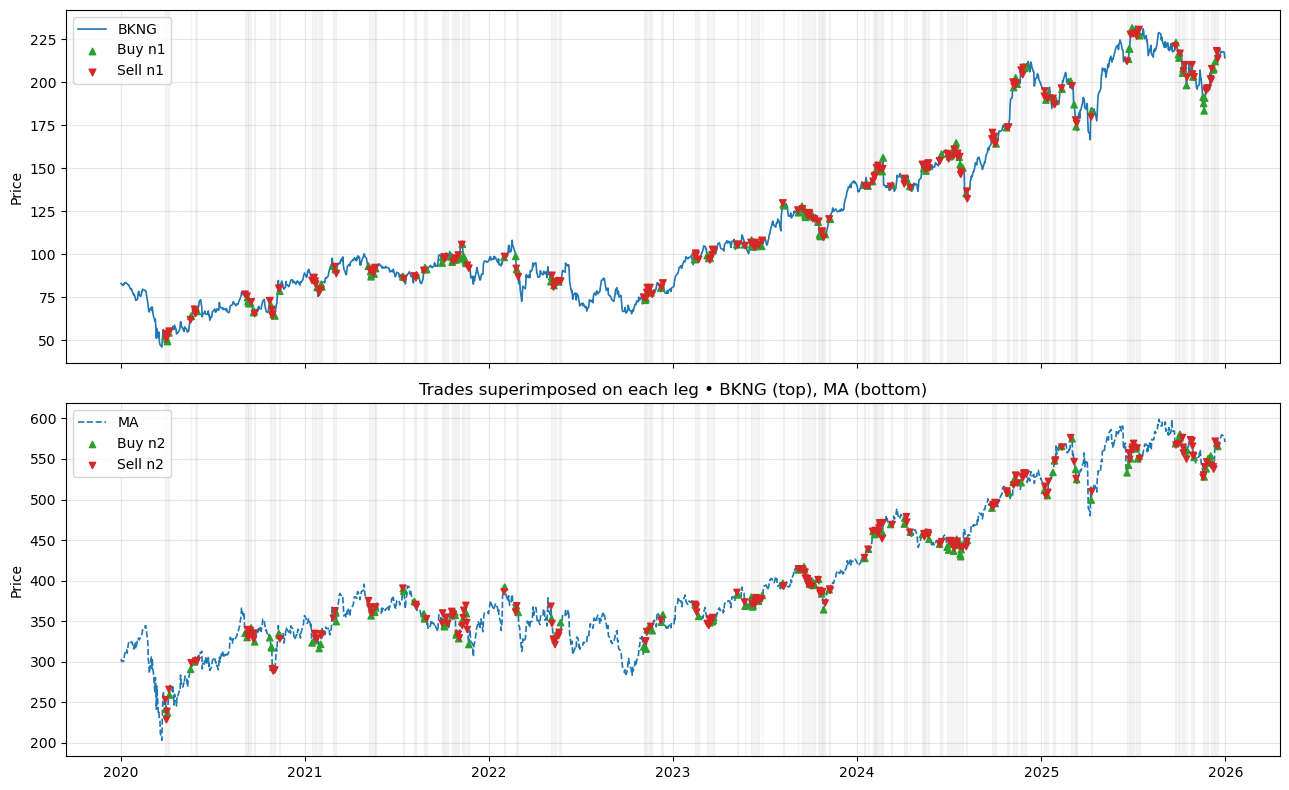

In [27]:

from pairs import plot_pair_legs_with_trades

plot_pair_legs_with_trades(
    df_pair_tuned, signals_tuned,
    label1=ticker1, label2=ticker2,
    normalize=False,
    shade_positions=True,
    size_scale=0.004,
    min_marker=20, max_marker=220,
)


## 4.4 In-sample performance metrics

In [28]:

from pairs import evaluate_pair_signals

COSTS = dict(cost_bps=1, fee_per_share_1=0.0, fee_per_share_2=0.0,
             borrow_bps_per_year=50, days_per_year=252, bars_per_year=252)

daily_tr,   trades_tr,   summary_tr   = evaluate_pair_signals(df_pair,       signals,       **COSTS)
daily_tr_t, trades_tr_t, summary_tr_t = evaluate_pair_signals(df_pair_tuned, signals_tuned, **COSTS)

print("=== In-Sample Performance (2020-01-02 → 2025-12-31) ===")
print(pd.DataFrame({"default": pd.Series(summary_tr), "tuned": pd.Series(summary_tr_t)}).to_string())


=== In-Sample Performance (2020-01-02 → 2025-12-31) ===
                                      default                tuned
start                     2020-01-02 00:00:00  2020-01-02 00:00:00
end                       2025-12-31 00:00:00  2025-12-31 00:00:00
bars                                     1508                 1508
capital_base                      10004.60448          9995.192892
gross_pnl                         1992.901453          3335.380849
net_pnl                           1794.505533          3140.161754
ann_return                            0.02869             0.051974
sharpe                               0.515717             0.866748
max_drawdown                       872.099587          1275.892263
max_drawdown_pct                     0.084032             0.120641
avg_gross_exposure                1698.151802          1782.992971
avg_exposure_utilization             0.999857             1.000017
turnover_annualized                 28.824608            28.218348
n_trad

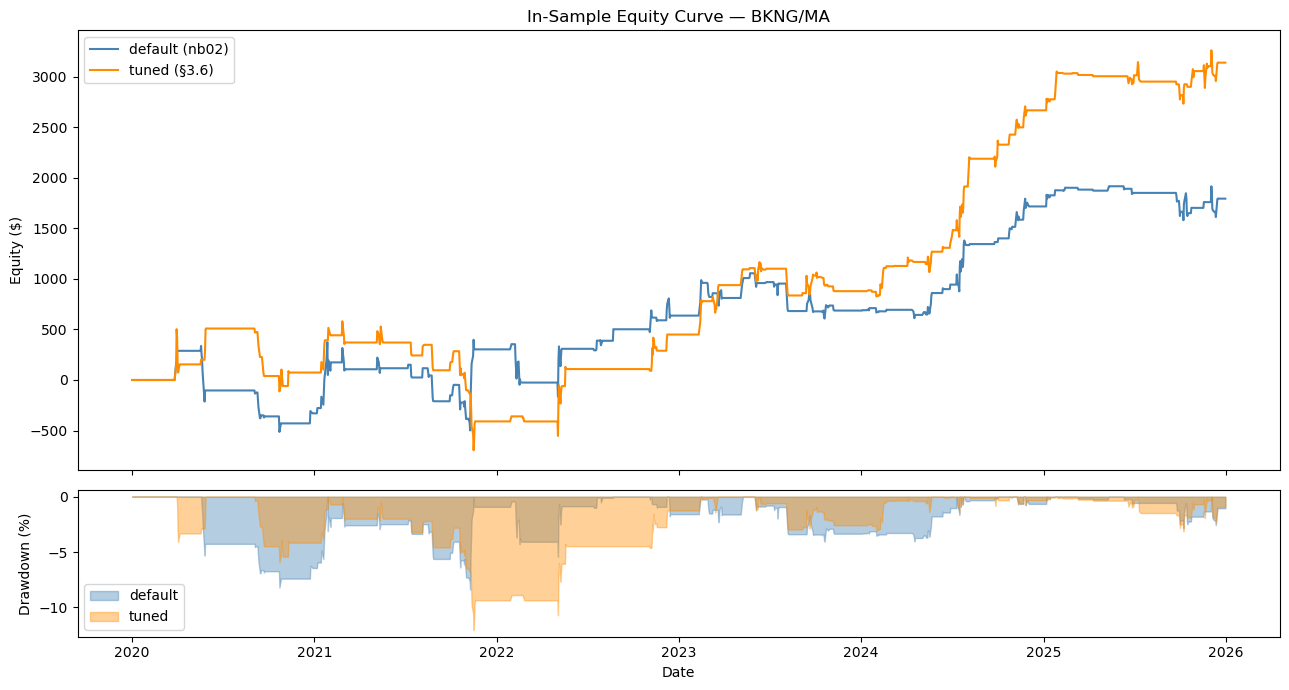

In [29]:

# Equity curves: default vs tuned (in-sample — the tuned curve is optimistic by construction)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
ax1.plot(daily_tr.index,   daily_tr["equity"],   color="steelblue", lw=1.5, label="default (nb02)")
ax1.plot(daily_tr_t.index, daily_tr_t["equity"], color="darkorange", lw=1.5, label="tuned (§3.6)")
ax1.set_ylabel("Equity ($)"); ax1.set_title(f"In-Sample Equity Curve — {ticker1}/{ticker2}"); ax1.legend()
ax2.fill_between(daily_tr.index,   daily_tr["drawdown_pct"] * 100,   0, alpha=0.4, color="steelblue", label="default")
ax2.fill_between(daily_tr_t.index, daily_tr_t["drawdown_pct"] * 100, 0, alpha=0.4, color="darkorange", label="tuned")
ax2.set_ylabel("Drawdown (%)"); ax2.set_xlabel("Date"); ax2.legend()
plt.tight_layout(); plt.show()



# 4b. Out-of-Sample Evaluation (2026-01-01 → 2026-06-25) — the only honest comparison

The tuned configuration was chosen on 2020–2025 folds; the default was chosen by hand. Both are now run
on the same 2026 window, which neither has seen. The Kalman filter is continued causally from each
configuration's own end-of-training state.


In [30]:

start_test = "2026-01-01"
end_test   = "2026-06-25"

_oos_cache = CACHE / f"nb04_oos_{ticker1}_{ticker2}.parquet"
if _oos_cache.exists():
    df_test, failed = pd.read_parquet(_oos_cache), []
else:
    df_test, failed = load_prices('openbb', [ticker1, ticker2], start_test, end_test, return_failed=True)
    df_test.to_parquet(_oos_cache)
print(f"OOS data: {len(df_test):,} rows, {df_test.index.get_level_values('ticker').nunique()} tickers")
if failed:
    print("No data for:", failed)


Download:   0%|          | 0/2 [00:00<?, ?it/s]

BKNG:   0%|          | 0/2 [00:00<?, ?it/s]    

BKNG:  50%|█████     | 1/2 [00:00<00:00,  3.89it/s]

MA:  50%|█████     | 1/2 [00:00<00:00,  3.89it/s]  

MA: 100%|██████████| 2/2 [00:00<00:00,  4.38it/s]

MA: 100%|██████████| 2/2 [00:00<00:00,  4.30it/s]

OOS data: 240 rows, 2 tickers


## 4b.2 Continue Kalman filter on OOS window (no look-ahead)

We freeze the parameters $(F, Q, R)$ learned during training and **continue filtering**
from the last train state.  The smoother is NOT used on OOS data — only the causal filter.

The OOS z-score uses a look-back chosen from — and warmed up on — the causal *training-window* residual under the same frozen parameters, so the OOS window never informs its own z-score.

In [31]:

from pairs import filter_kf_on_new

P1_new = df_test.loc[(ticker1,), 'close']
P2_new = df_test.loc[(ticker2,), 'close']
prices_te = df_test.pivot_table(
    index=df_test.index.get_level_values("datetime"),
    columns=df_test.index.get_level_values("ticker"),
    values="close",
)

def _continue(params):
    frozen = {k: params[k] for k in ("F", "Q", "R")}
    last_state = (params["last_state_mean"], params["last_state_cov"])
    states_te, _ = filter_kf_on_new(P1_new, P2_new, frozen=frozen, last_state=last_state, init_cov=1e6, mode="filter")
    df_te = states_te.join(prices_te[[ticker1, ticker2]].rename(columns={ticker1: "P1", ticker2: "P2"}), how="inner")
    # Causal residual over the TRAINING window under the same frozen parameters: it sets the z-score
    # look-back and warms it up, so the OOS window never informs its own z-score (nb02's fix).
    states_hist, _ = filter_kf_on_new(df_pair["P1"], df_pair["P2"], frozen=frozen, last_state=None, init_cov=1e6, mode="filter")
    return df_te, states_hist["resid"]

df_pair_te,   z_hist_default = _continue(params_tr[pair])       # default Kalman, continued
df_pair_te_t, z_hist_tuned   = _continue(params_tuned[pair])    # tuned Kalman, continued
print(f"OOS pair frame: {df_pair_te.index[0].date()} → {df_pair_te.index[-1].date()}, {len(df_pair_te):,} bars")
print(f"z-score windows from training residual — default: {estimate_halflife_window(z_hist_default)} bars, "
      f"tuned: {estimate_halflife_window(z_hist_tuned)} bars")


OOS pair frame: 2026-01-02 → 2026-06-25, 120 bars
z-score windows from training residual — default: 30 bars, tuned: 30 bars


In [32]:

signals_te   = generate_pair_signals(df_pair_te,   capital_per_pair=10_000, z_history=z_hist_default,
                                     z_window=estimate_halflife_window(z_hist_default), **SIG_DEFAULT)
signals_te_t = generate_pair_signals(df_pair_te_t, capital_per_pair=10_000, z_history=z_hist_tuned,
                                     z_window=estimate_halflife_window(z_hist_tuned), **SIG_TUNED)

daily_te,   trades_te,   summary_te   = evaluate_pair_signals(df_pair_te[["P1", "P2"]],   signals_te,   **COSTS)
daily_te_t, trades_te_t, summary_te_t = evaluate_pair_signals(df_pair_te_t[["P1", "P2"]], signals_te_t, **COSTS)

print("=== Out-of-Sample Performance (2026-01-01 → 2026-06-25) ===")
print(pd.DataFrame({"default": pd.Series(summary_te), "tuned": pd.Series(summary_te_t)}).to_string())


=== Out-of-Sample Performance (2026-01-01 → 2026-06-25) ===
                                      default                tuned
start                     2026-01-02 00:00:00  2026-01-02 00:00:00
end                       2026-06-25 00:00:00  2026-06-25 00:00:00
bars                                      120                  120
capital_base                      9994.934405          9920.042188
gross_pnl                          829.810073           706.887197
net_pnl                            800.118659           680.790473
ann_return                           0.181645             0.152674
sharpe                               3.499967             2.281459
max_drawdown                       142.512322           180.400418
max_drawdown_pct                     0.013461             0.017875
avg_gross_exposure                2168.820124           2411.82053
avg_exposure_utilization             1.001501             1.006039
turnover_annualized                 56.810331            48.907756
n_

## 4b.3 Visualise OOS trades (tuned configuration)

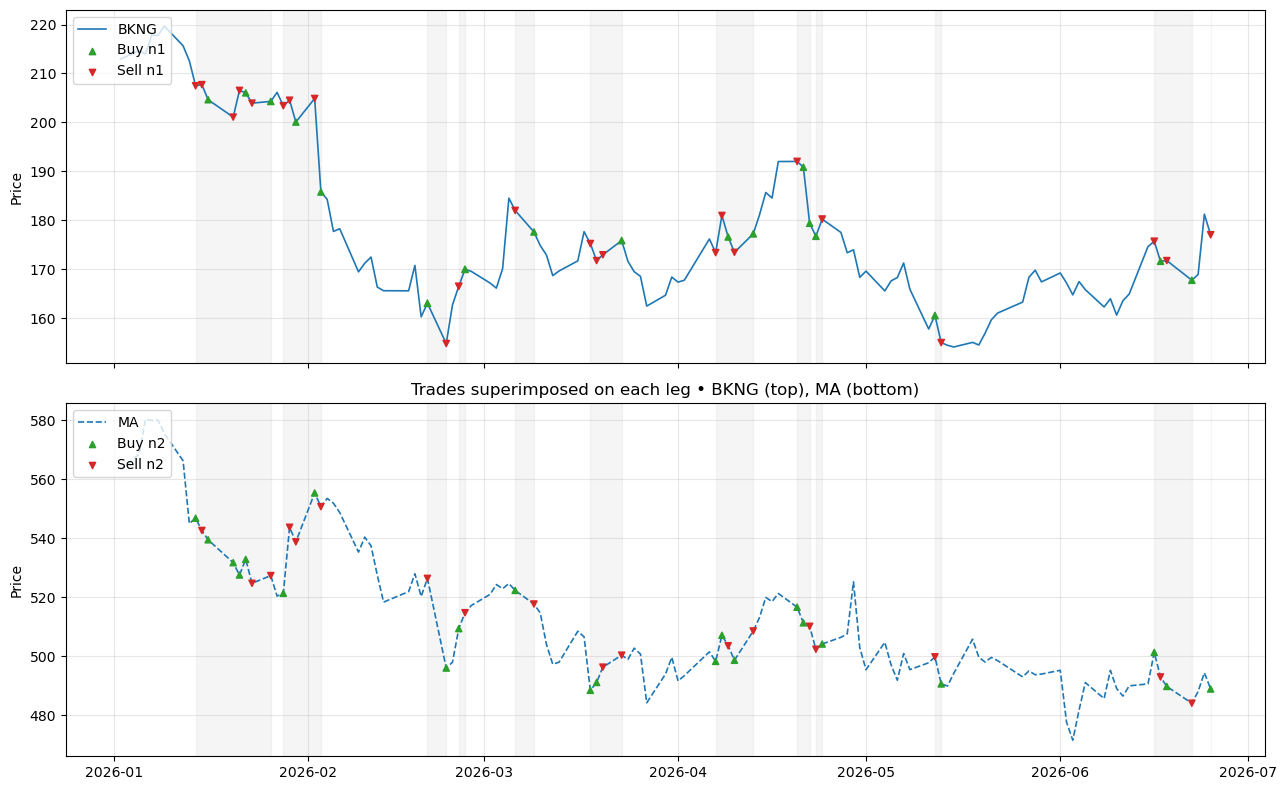

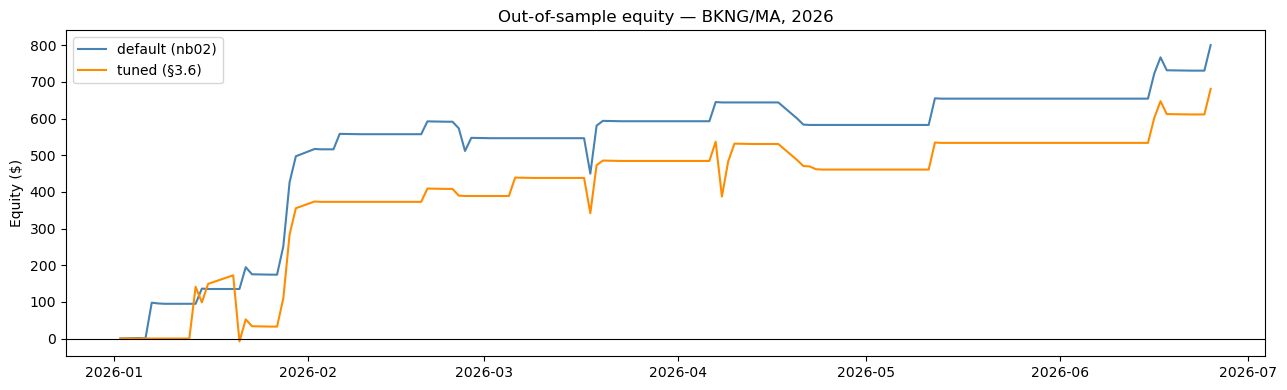

In [33]:

from pairs import plot_pair_legs_with_trades

plot_pair_legs_with_trades(
    df_pair_te_t, signals_te_t,
    label1=ticker1, label2=ticker2,
    normalize=False,
    shade_positions=True,
    size_scale=0.004,
    min_marker=20, max_marker=220,
)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(daily_te.index,   daily_te["equity"],   color="steelblue",  lw=1.5, label="default (nb02)")
ax.plot(daily_te_t.index, daily_te_t["equity"], color="darkorange", lw=1.5, label="tuned (§3.6)")
ax.axhline(0, color="black", lw=0.8)
ax.set_title(f"Out-of-sample equity — {ticker1}/{ticker2}, 2026"); ax.set_ylabel("Equity ($)"); ax.legend()
plt.tight_layout(); plt.show()



## 4b.4 In-sample vs OOS, default vs tuned

Two things to keep in mind when reading the table:

* The **in-sample** columns use nb02's causally-filtered Kalman states, with the EM noise parameters fitted
  on the whole training window. No bar's signal sees its own future, but the parameters were chosen with
  the window in hand, so these columns still flatter both configurations and can rank them differently
  from the walk-forward folds. The pooled out-of-fold Sharpe and equity curve in §3.6 are the right
  in-sample yardstick; the IS columns are here for continuity with nb02.
* The **OOS** columns are the evidence, but half a year yields a handful of trades: they can show a tuned
  configuration failing, they cannot show it succeeding with any confidence.


In [34]:

rows = ["sharpe", "ann_return", "max_drawdown_pct", "n_trades", "hit_rate", "profit_factor"]
comparison = pd.DataFrame({
    "IS default": pd.Series(summary_tr),   "IS tuned": pd.Series(summary_tr_t),
    "OOS default": pd.Series(summary_te),  "OOS tuned": pd.Series(summary_te_t),
}).loc[rows]
comparison.loc["ann_return"] = comparison.loc["ann_return"] * 100
comparison.index = ["Sharpe", "Ann. Return (%)", "Max Drawdown (%)", "Trades", "Hit Rate", "Profit Factor"]
print(comparison.to_string(float_format="{:.3f}".format))


                 IS default IS tuned OOS default OOS tuned
Sharpe                0.516    0.867       3.500     2.281
Ann. Return (%)       2.869    5.197      18.164    15.267
Max Drawdown (%)      0.084    0.121       0.013     0.018
Trades                   85       83          13        11
Hit Rate              0.600    0.578       0.846     0.727
Profit Factor         1.607    2.195       8.122     8.224


## 4b.5 What this tuning run actually found

Numbers refer to the run stored in this notebook (deterministic given the cached prices; a fresh
download shifts them slightly). The objective is the pooled out-of-fold Sharpe of §3.6; nb02's per-fold
median is reported alongside.

* **The grid finds "better" configurations easily.** The best pooled out-of-fold Sharpe is 1.38 against
  0.71 for nb02's defaults, which rank around 300th of ~1,950 valid configurations — and the defaults sit
  above the median of every marginal group in §3.6.1, so by the grid's own standards they are a good
  configuration. The winner is a *stiffer and quieter* strategy: `q=1e-6` with no EM (a nearly static
  hedge ratio), rolling rather than robust z-scores, entry at 2.5 and exit at 1.0 — in position for 104
  of the 1,004 out-of-fold bars against 218 for the default, and about a third as many trades (45 vs 149
  on the folds, 26 vs 86 in the full in-sample run). It is the same configuration family that wins under
  nb02's per-fold median (2.02 vs 0.96), so the two objectives agree on the winner.
* **The pooled equity curve (§3.6.4) is the honest in-sample comparison**, and it is far less dramatic
  than the smoothed §4 curves: both configurations make money out of fold, roughly +$3,500 and +$4,400 on
  a $10k base over 2022–2025, the tuned one with fewer, longer holding periods and without the default's
  2025 drawdown.
* **The ranking is not reproducible across fold halves.** Under the pooled objective, configurations
  ranked on the odd folds have a median rank of ~1,190 of ~1,930 on the even folds — no better than chance
  (~965) — and the Spearman correlation between the two rankings is −0.18. The winner itself scores well on
  both halves (about 1.35 and 1.45), but the ordering of the rest of the grid is noise: with two to ten
  trades per 63-bar segment, a pooled Sharpe over eight segments is dominated by a few large days. nb02's
  per-fold median gave a more stable ranking (ρ ≈ 0.44), at the price of ignoring how much of the time a
  configuration is invested.
* **It transfers poorly.** On the runner-up pairs the tuned configuration helps NCLH/TEL (0.20 → 0.60) and
  hurts CCL/EXPE (0.41 → 0.15) and NCLH/SPG (0.61 → −0.01) (§3.6.3).
* **Out of sample it did not help.** On the 2026 hold-out the default made seven trades, six of them
  winners (Sharpe 1.4), while the tuned configuration made two, one of them a loser (Sharpe −0.4). With
  two to seven trades neither number is statistically meaningful, but the direction is the one selection
  bias predicts.

The honest reading: the winner is a genuine description of CCL/STT's 2020–2025 behaviour — a static
hedge, wide entry, early exit — that both objectives pick out, but it is not evidence about the *strategy*:
it does not transfer to neighbouring pairs, it loses on the hold-out, and the rest of the grid's ranking
is noise. What the exercise does establish is *which* knobs matter on this pair (§3.6.1): the exit
threshold dominates (exiting only at the mean, `z_exit=0`, is clearly worse than 0.5 or 1.0), the entry
threshold has a mild optimum near 2.5, rolling z-scores edge out robust ones, a holding cap or a cooldown
costs a little, and the Kalman noise, `em_iters` and `z_stop` barely register. A sensible next step is a
much smaller search over `z_exit` and `z_entry` only, pooled across the shortlist rather than fitted to
one pair.

# 8. Limitations and Honest Assessment

## 8.1 What the results cannot tell us

The traded pair was chosen (§3.5) from a shortlist that itself survived a composite stationarity filter over a very large number of simultaneously-tested pairs. Read the performance with these caveats:

- **Selection bias.** Even with BH FDR correction *and* walk-forward-based selection, picking the best-ranked pair on validation folds inflates expectations. The OOS test window is held out, but validation-set selection bias remains.
- **Low OOS trade count.** The OOS window typically produces only a handful of trades (7 for the selected CCL/STT pair) — far below the ~50 needed for statistical power. A high hit rate on a few trades is uninformative.
- **OOS Sharpe decay.** In-sample Sharpe is systematically optimistic and the OOS figure is typically much lower. Likely causes: over-fitting to COVID-era volatility, cointegration breakdown, and regimes (e.g. an AI bull market) offering fewer reversion opportunities.
- **Optimistic cost model.** The in-sample/OOS evaluation uses a flat `cost_bps` with no market impact, fill/queue uncertainty, or borrow-availability variability.
- **Single-pair analysis.** A live strategy trades a *portfolio* of pairs — introducing cross-pair residual correlation, portfolio-level drawdown management, and signal interaction effects not captured here.

## 8.2 What the evidence does support

1. A working end-to-end pipeline (data → cointegration → Kalman hedge → signals → evaluation) with **causal OOS continuation** (no look-ahead: the Kalman state is carried forward, and the z-score look-back and its warm-up come from training data, never from the window being scored).
2. **Honest pair selection**: the traded pair is chosen by walk-forward cross-fold stability (§3.5), not by in-sample ranking — and the held-out window is never used for selection.
3. **Multiple-testing handled**: BH FDR correction removes statistically spurious pairs.
4. **Honest degradation disclosure**: the OOS Sharpe is reported, not hidden, and the walk-forward distribution (§3.5.1) shows the spread across folds rather than one window.

## 8.3 Gap-to-production

| Gap | Required mitigation |
|-----|---------------------|
| Selection bias | Strict hold-out from inception; FDR + walk-forward selection already applied |
| Low OOS N | Longer OOS window; portfolio of 10+ pairs |
| No market impact | Square-root impact model + capacity analysis |
| Single-regime OOS | Rolling re-estimation in live trading |
| No portfolio risk mgmt | Residual-vol position sizing; cross-pair correlation |
| Borrow / execution | Pre-borrow checks; limit-order fill model |

### Tuning-specific caveats (this notebook)

* **One pair, one search.** The grid was scored on the selected pair's folds. The transfer check in
  §3.6.3 is a sanity check, not a portfolio-level validation; a configuration tuned across the whole
  shortlist (pooled objective) would be the next step.
* **Selection bias is not removed, only exposed.** Thousands of configurations are compared on the same
  16 folds; §3.6.2 shows how the winner sits relative to the bulk and whether rankings agree across
  fold halves, but only the 2026 hold-out is an unbiased read — and half a year is a short one.
* **The pair was selected with the default parameters.** Selection and tuning interact; tuning first
  and selecting afterwards (or jointly) changes which pair is traded.
* **Fixed costs, fixed folds.** Cost assumptions (1 bp, 50 bp/yr borrow) and the fold geometry
  (504/126/63) are not tuned and the results are conditional on them.
